FuncAnimation de Matplotlib permite animar artistas (líneas, scatter, textos) actualizando su estado en cada frame. Usaremos NumPy para generar datos y la API orientada a objetos para controlar la animación.

13.1 Introducción a FuncAnimation

fig: figura a animar.
func(i): actualiza artistas y retorna una lista/tupla de objetos.
init_func(): estado inicial (opcional, necesario para blitting).
frames: número de frames o iterador.
interval: milisegundos entre frames.
blit=True: redibuja solo lo que cambia.
💡 Devolvé siempre los artistas modificados y utilizá set_* (por ejemplo, line.set_data) en cada frame.

13.2 Animación de una onda sinusoidal
Onda viajera (una línea)

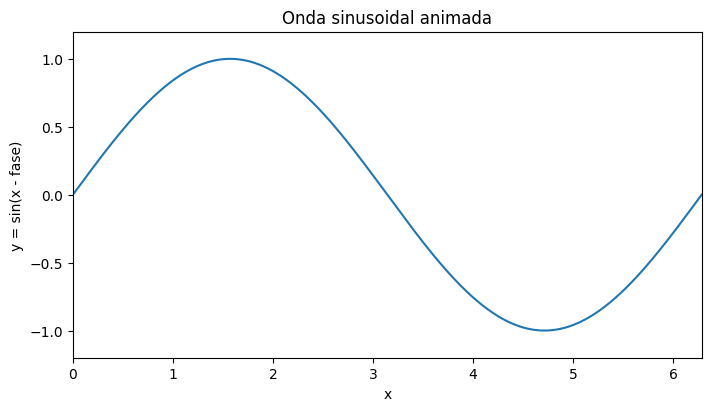

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

x = np.linspace(0, 2 * np.pi, 600)
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
(line,) = ax.plot(x, np.sin(x))
ax.set_xlim(x.min(), x.max())
ax.set_ylim(-1.2, 1.2)
ax.set_title("Onda sinusoidal animada")
ax.set_xlabel("x")
ax.set_ylabel("y = sin(x - fase)")

def init():
    line.set_ydata(np.sin(x))
    return (line,)

def update(frame):
    fase = 0.05 * frame
    line.set_ydata(np.sin(x - fase))
    return (line,)

ani = FuncAnimation(
    fig,
    update,
    frames=200,
    init_func=init,
    interval=20,
    blit=True,
    repeat=True
)
plt.show()

Dos líneas y anotación

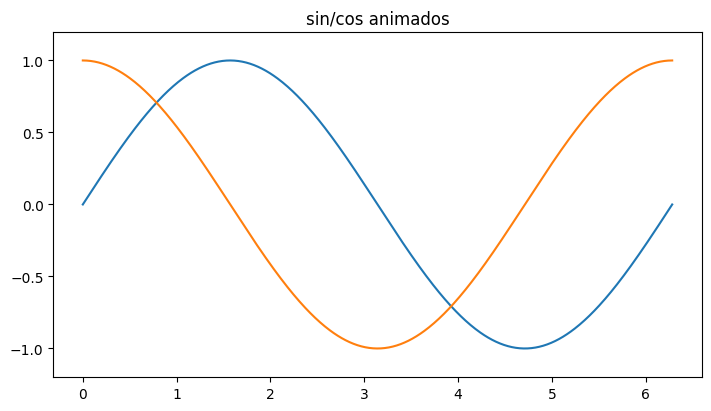

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

x = np.linspace(0, 2 * np.pi, 600)
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
line1, = ax.plot(x, np.sin(x))
line2, = ax.plot(x, np.cos(x))
txt = ax.text(0.02, 0.90, "", transform=ax.transAxes)
ax.set_ylim(-1.2, 1.2)
ax.set_title("sin/cos animados")

def init():
    line1.set_ydata(np.sin(x))
    line2.set_ydata(np.cos(x))
    txt.set_text("")
    return (line1, line2, txt)

def update(i):
    fase = 0.04 * i
    line1.set_ydata(np.sin(x - fase))
    line2.set_ydata(np.cos(x - fase))
    txt.set_text(f"frame: {i}")
    return (line1, line2, txt)

ani = FuncAnimation(
    fig,
    update,
    frames=250,
    init_func=init,
    interval=20,
    blit=True
)
plt.show()

13.3 Guardar animaciones en GIF o MP4
Para guardar, necesitás un writer disponible en tu entorno. Comprobálo con matplotlib.animation.writers.list().

Guardar como GIF

In [3]:
from matplotlib.animation import PillowWriter

# ani = FuncAnimation(...)
writer = PillowWriter(fps=30)
ani.save("onda.gif", writer=writer, dpi=100)

Guardar como MP4

In [4]:
from matplotlib.animation import FFMpegWriter

# ani = FuncAnimation(...)
writer = FFMpegWriter(fps=30, bitrate=1800)
ani.save("onda.mp4", writer=writer, dpi=120)

FileNotFoundError: [WinError 2] El sistema no puede encontrar el archivo especificado

💡 Asegurate de tener FFmpeg instalado (PATH en Windows o gestor de paquetes en Linux/macOS).

13.4 Rendimiento y buenas prácticas
Usá blit=True cuando sea posible.
Evitá crear artistas nuevos en cada frame; utilizá set_*.
Mantené límites fijados con set_xlim/set_ylim.
Si la lógica por frame es pesada, precomputá o muestreá.
En notebooks, elige entre %matplotlib inline o %matplotlib widget para embebido.

13.5 Patrón reusable

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

def build_animation(fps=30, frames=300, save=None):
    x = np.linspace(0, 2 * np.pi, 800)
    fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
    (line,) = ax.plot(x, np.sin(x))
    ax.set_ylim(-1.2, 1.2)
    ax.set_title("Patrón reusable")

    def init():
        line.set_ydata(np.sin(x))
        return (line,)

    def update(i):
        phase = 2 * np.pi * (i / frames)
        line.set_ydata(np.sin(x - phase))
        return (line,)

    ani = FuncAnimation(
        fig,
        update,
        init_func=init,
        frames=frames,
        interval=1000 // fps,
        blit=True
    )

    if save:
        if save.endswith(".mp4"):
            ani.save(save, writer=FFMpegWriter(fps=fps, bitrate=2000), dpi=120)
        elif save.endswith(".gif"):
            from matplotlib.animation import PillowWriter
            ani.save(save, writer=PillowWriter(fps=fps), dpi=100)
    return ani

💡 Ajustá fps, frames, dpi y bitrate según el medio de destino (web, video, presentaciones).

Checklist final
Creá la animación con FuncAnimation(fig, update, frames, init_func, interval, blit).

Actualizá artistas existentes (set_data, set_text, etc.).

Guardá con PillowWriter (GIF) o FFMpegWriter (MP4) ajustando calidad y tamaño.